In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ pandas  :", pd.__version__)
print("✅ numpy   :", np.__version__)
print("✅ seaborn :", sns.__version__)
print("\n🎉 Sẵn sàng!")

✅ pandas  : 3.0.1
✅ numpy   : 2.4.3
✅ seaborn : 0.13.2

🎉 Sẵn sàng!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

# Load file CSV
df = pd.read_csv('data/online_retail_II.csv', encoding='utf-8')

print(f"✅ Total shape : {df.shape}")
print(f"\n📋 Columns: {df.columns.tolist()}")
print(f"\n5 dòng đầu:")
df.head()

✅ Total shape : (1067371, 8)

📋 Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

5 dòng đầu:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print("=" * 55)
print("  BASIC INFO")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("  MISSING VALUES")
print("=" * 55)
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
for col, m, p in zip(missing.index, missing, pct):
    bar = '█' * int(p) + '░' * (10 - int(p))
    print(f"  {col:<15}: [{bar}] {p:5.2f}%  ({m:,})")

print("\n" + "=" * 55)
print("  BASIC STATISTICS")
print("=" * 55)
print(f"  Tổng giao dịch  : {len(df):>12,}")
print(f"  Unique Customers: {df['Customer ID'].nunique():>12,}")
print(f"  Unique Products : {df['StockCode'].nunique():>12,}")
print(f"  Unique Countries: {df['Country'].nunique():>12,}")
print(f"  Date range      : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")

  BASIC INFO
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

  MISSING VALUES
  Invoice        : [░░░░░░░░░░]  0.00%  (0)
  StockCode      : [░░░░░░░░░░]  0.00%  (0)
  Description    : [░░░░░░░░░░]  0.41%  (4,382)
  Quantity       : [░░░░░░░░░░]  0.00%  (0)
  InvoiceDate    : [░░░░░░░░░░]  0.00%  (0)
  Price          : [░░░░░░░░░░]  0.00%  (0)
  Customer ID    : [██████████████████████] 22.77%  (243,007)
  Country        : [░░░░░░░░░░]  0.00%  (0)

  BASIC STATISTICS
  Tổng giao dịch  :    1,067,371
  Unique Customers:        5,942
  Unique Products :        5,305
  Unique Countries:           43
  Date range      : 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [4]:
# Bước 1: Xóa dòng không có Customer ID
# (không có CustomerID thì không thể tính RFM)
df_clean = df.dropna(subset=['Customer ID']).copy()

# Bước 2: Chuyển Customer ID thành integer
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# Bước 3: Chuyển InvoiceDate thành datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Bước 4: Xóa đơn hàng bị hủy (Invoice bắt đầu bằng 'C')
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Bước 5: Xóa dòng có Quantity hoặc Price <= 0
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]

# Bước 6: Tạo cột TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

print(f"✅ Trước khi clean : {len(df):>10,} dòng")
print(f"✅ Sau khi clean   : {len(df_clean):>10,} dòng")
print(f"✅ Đã loại bỏ      : {len(df)-len(df_clean):>10,} dòng")
print(f"\n📅 Date range: {df_clean['InvoiceDate'].min().date()} "
      f"→ {df_clean['InvoiceDate'].max().date()}")
print(f"👥 Unique Customers: {df_clean['Customer ID'].nunique():,}")
print(f"💰 Total Revenue   : {df_clean['TotalPrice'].sum():,.2f}")

✅ Trước khi clean :  1,067,371 dòng
✅ Sau khi clean   :    805,549 dòng
✅ Đã loại bỏ      :    261,822 dòng

📅 Date range: 2009-12-01 → 2011-12-09
👥 Unique Customers: 5,878
💰 Total Revenue   : 17,743,429.18


In [5]:
# Ngày tham chiếu = ngày mua cuối cùng + 1 ngày
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"📅 Reference date: {reference_date.date()}")

# Tính R, F, M cho từng khách hàng
rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f"\n✅ RFM shape: {rfm.shape}")
print(f"\n📊 RFM Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))
print(f"\n5 dòng đầu:")
rfm.head()

📅 Reference date: 2011-12-10

✅ RFM shape: (5878, 4)

📊 RFM Statistics:
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    3018.62
std     209.34      13.01   14737.73
min       1.00       1.00       2.95
25%      26.00       1.00     348.76
50%      96.00       3.00     898.92
75%     380.00       7.00    2307.09
max     739.00     398.00  608821.65

5 dòng đầu:


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [6]:
# Chấm điểm R: mua càng gần đây → điểm càng cao
# Nên Recency thấp = tốt → reverse
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                          q=5,
                          labels=[5, 4, 3, 2, 1])

# Chấm điểm F: mua càng nhiều lần → điểm càng cao
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5,
                          labels=[1, 2, 3, 4, 5])

# Chấm điểm M: chi tiêu càng nhiều → điểm càng cao
rfm['M_Score'] = pd.qcut(rfm['Monetary'],
                          q=5,
                          labels=[1, 2, 3, 4, 5])

# Chuyển sang integer
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Tạo RFM Score tổng hợp
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) +
                    rfm['F_Score'].astype(str) +
                    rfm['M_Score'].astype(str))

# Tạo điểm tổng
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("✅ Điểm RFM đã tính xong!")
print(f"\n📊 Phân phối R_Score:")
print(rfm['R_Score'].value_counts().sort_index())
print(f"\n📊 Phân phối F_Score:")
print(rfm['F_Score'].value_counts().sort_index())
print(f"\n📊 Phân phối M_Score:")
print(rfm['M_Score'].value_counts().sort_index())
rfm.head()

✅ Điểm RFM đã tính xong!

📊 Phân phối R_Score:
R_Score
1    1175
2    1172
3    1167
4    1176
5    1188
Name: count, dtype: int64

📊 Phân phối F_Score:
F_Score
1    1176
2    1175
3    1176
4    1175
5    1176
Name: count, dtype: int64

📊 Phân phối M_Score:
M_Score
1    1176
2    1175
3    1176
4    1175
5    1176
Name: count, dtype: int64


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,12,77556.46,2,5,5,255,12
1,12347,2,8,5633.32,5,4,5,545,14
2,12348,75,5,2019.40,3,4,4,344,11
3,12349,19,4,4428.69,5,3,5,535,13
4,12350,310,1,334.40,2,1,2,212,5


In [7]:
def segment_customer(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r == 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Thống kê theo segment
segment_stats = rfm.groupby('Segment').agg(
    Customers  = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean'),
    Total_Revenue = ('Monetary',  'sum')
).round(2).reset_index()

segment_stats['Revenue_%'] = (
    segment_stats['Total_Revenue'] /
    segment_stats['Total_Revenue'].sum() * 100
).round(2)

segment_stats = segment_stats.sort_values(
    'Total_Revenue', ascending=False
)

print("✅ Phân khúc khách hàng hoàn tất!")
print(f"\n{'='*65}")
print(f"{'Segment':<22} {'Customers':>9} {'Avg_M':>10} {'Revenue_%':>10}")
print(f"{'='*65}")
for _, row in segment_stats.iterrows():
    print(f"  {row['Segment']:<20} {row['Customers']:>9,} "
          f"{row['Avg_Monetary']:>10,.2f} {row['Revenue_%']:>9.2f}%")
print(f"{'='*65}")

✅ Phân khúc khách hàng hoàn tất!

Segment                Customers      Avg_M  Revenue_%
  Champions                1,300   9,329.32     68.35%
  Loyal Customers          1,134   2,295.58     14.67%
  At Risk                    615   2,517.23      8.72%
  Hibernating                510     854.62      2.46%
  New Customers              443     890.83      2.22%
  Lost                     1,275     256.98      1.85%
  Potential Loyalists        356     602.15      1.21%
  Promising                  245     373.58      0.52%


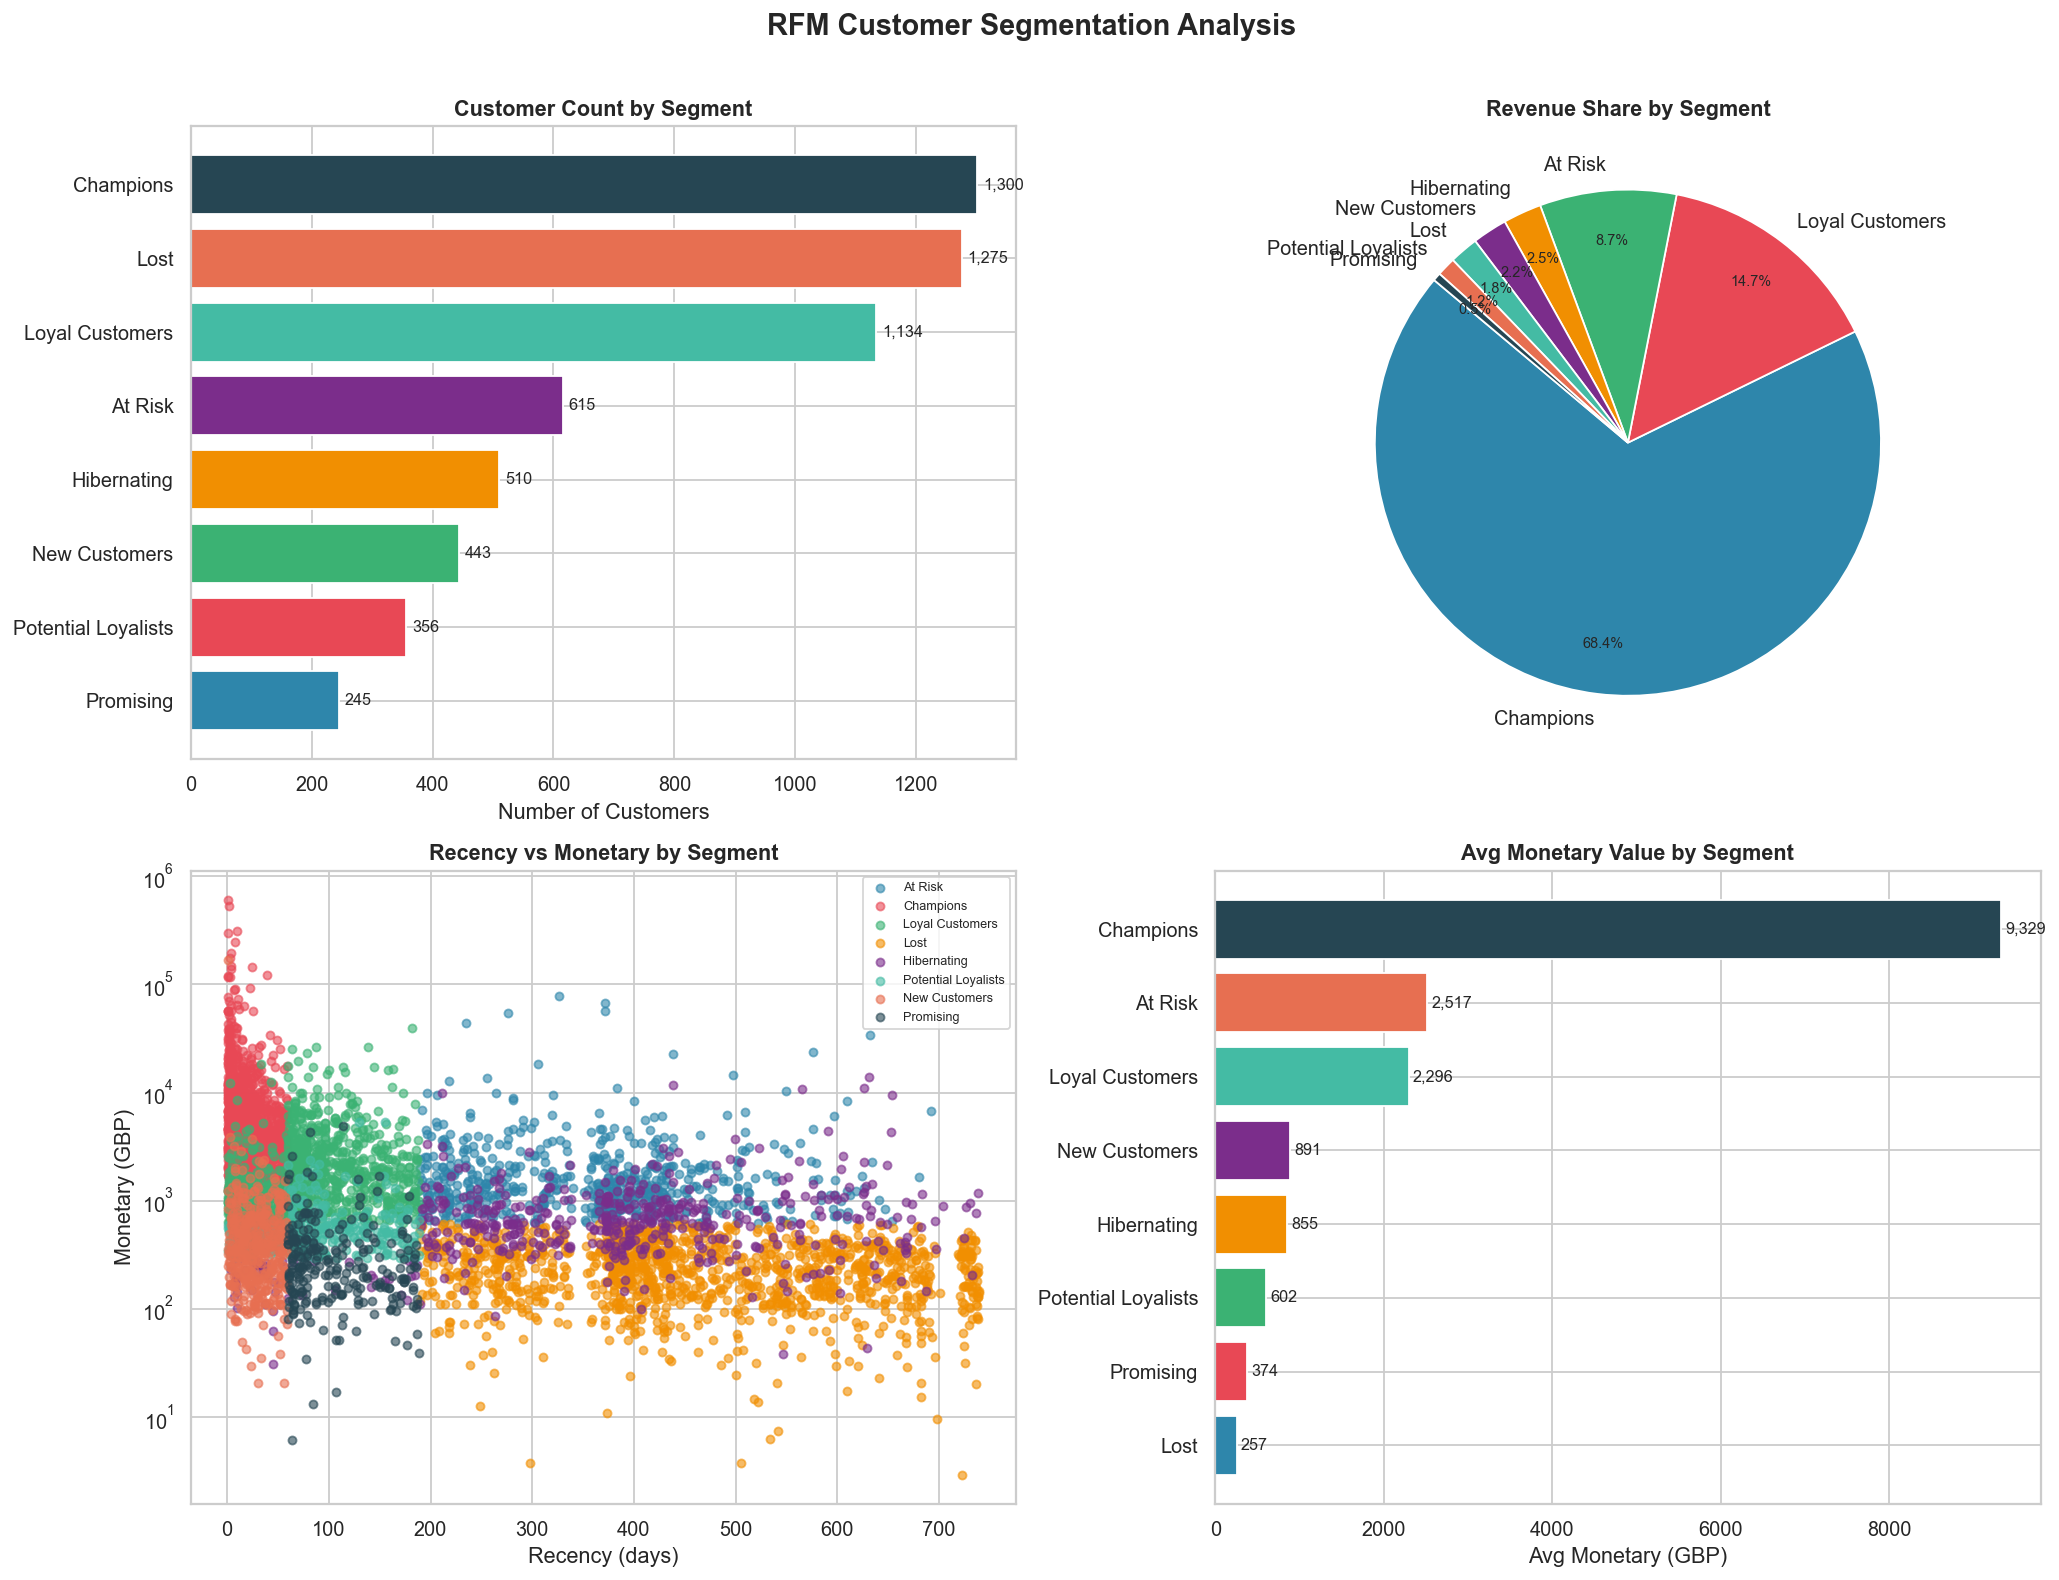

✅ Chart saved!


In [9]:
import os
os.makedirs('charts', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('RFM Customer Segmentation Analysis',
             fontsize=16, fontweight='bold', y=1.01)

COLORS = ['#2E86AB','#E84855','#3BB273','#F18F01',
          '#7B2D8B','#44BBA4','#E76F51','#264653','#A8DADC']

# Chart 1 — Số khách theo Segment
ax1 = axes[0, 0]
seg_count = segment_stats.sort_values('Customers', ascending=True)
bars = ax1.barh(seg_count['Segment'], seg_count['Customers'],
                color=COLORS[:len(seg_count)])
ax1.set_title('Customer Count by Segment', fontweight='bold')
ax1.set_xlabel('Number of Customers')
for bar, val in zip(bars, seg_count['Customers']):
    ax1.text(val + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

# Chart 2 — Doanh thu theo Segment (Pie)
ax2 = axes[0, 1]
wedges, texts, autotexts = ax2.pie(
    segment_stats['Total_Revenue'],
    labels=segment_stats['Segment'],
    autopct='%1.1f%%',
    colors=COLORS[:len(segment_stats)],
    startangle=140,
    pctdistance=0.8)
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title('Revenue Share by Segment', fontweight='bold')

# Chart 3 — Recency vs Monetary Scatter
ax3 = axes[1, 0]
segments = rfm['Segment'].unique()
for i, seg in enumerate(segments):
    mask = rfm['Segment'] == seg
    ax3.scatter(rfm[mask]['Recency'],
                rfm[mask]['Monetary'],
                label=seg, alpha=0.6, s=20,
                color=COLORS[i % len(COLORS)])
ax3.set_title('Recency vs Monetary by Segment',
              fontweight='bold')
ax3.set_xlabel('Recency (days)')
ax3.set_ylabel('Monetary (GBP)')
ax3.legend(fontsize=7, loc='upper right')
ax3.set_yscale('log')

# Chart 4 — Avg Monetary theo Segment
ax4 = axes[1, 1]
seg_money = segment_stats.sort_values('Avg_Monetary',
                                       ascending=True)
bars4 = ax4.barh(seg_money['Segment'],
                  seg_money['Avg_Monetary'],
                  color=COLORS[:len(seg_money)])
ax4.set_title('Avg Monetary Value by Segment',
              fontweight='bold')
ax4.set_xlabel('Avg Monetary (GBP)')
for bar, val in zip(bars4, seg_money['Avg_Monetary']):
    ax4.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/rfm_analysis.png',
            dpi=140, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [10]:
import os
os.makedirs('data', exist_ok=True)

# File 1 — RFM chính
rfm.to_csv('data/powerbi_rfm.csv', index=False)
print(f"✅ powerbi_rfm.csv        — {len(rfm):,} rows")

# File 2 — Segment summary
segment_stats.to_csv('data/powerbi_segments.csv', index=False)
print(f"✅ powerbi_segments.csv   — {len(segment_stats):,} rows")

# File 3 — Doanh thu theo tháng
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
monthly = df_clean.groupby('YearMonth').agg(
    Revenue  = ('TotalPrice', 'sum'),
    Orders   = ('Invoice',    'nunique'),
    Customers= ('Customer ID','nunique')
).reset_index()
monthly.to_csv('data/powerbi_monthly.csv', index=False)
print(f"✅ powerbi_monthly.csv    — {len(monthly):,} rows")

# File 4 — Top countries
country = df_clean.groupby('Country').agg(
    Revenue  = ('TotalPrice', 'sum'),
    Orders   = ('Invoice',    'nunique'),
    Customers= ('Customer ID','nunique')
).reset_index().sort_values('Revenue', ascending=False)
country.to_csv('data/powerbi_country.csv', index=False)
print(f"✅ powerbi_country.csv    — {len(country):,} rows")

print("\n🎉 Export hoàn tất! Sẵn sàng cho Power BI!")

✅ powerbi_rfm.csv        — 5,878 rows
✅ powerbi_segments.csv   — 8 rows
✅ powerbi_monthly.csv    — 25 rows
✅ powerbi_country.csv    — 41 rows

🎉 Export hoàn tất! Sẵn sàng cho Power BI!
